# Data Quality Verification (EDA) - IUM Project Task 7
## Objective: Confirm readiness of the new data package for building a predictive model (Phase 2).

In this iteration of the analysis we examine data completeness after fixing identifiers, analyze the distribution of stay lengths, and verify the predictive potential of features (correlations with the target).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../results', exist_ok=True)

In [2]:
df_listings = pd.read_csv('../data/raw/listings.csv')
df_sessions = pd.read_csv('../data/raw/sessions.csv')

df_listings['price_num'] = df_listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True)
df_listings['price_num'] = pd.to_numeric(df_listings['price_num'], errors='coerce')

bookings = df_sessions[df_sessions['action'] == 'book_listing'].copy()
bookings['booking_date'] = pd.to_datetime(bookings['booking_date'], errors='coerce')
bookings['booking_duration'] = pd.to_datetime(bookings['booking_duration'], errors='coerce')
bookings['stay_length_days'] = (bookings['booking_duration'] - bookings['booking_date']).dt.days

print("Number of all 'book_listing' events:", len(bookings))

Number of all 'book_listing' events: 228021


## 1. Data Completeness Verification (Table Integration)
We check whether the fixed primary and foreign keys allow correct joining of session history with listing features without losing rows.

In [3]:
total_bookings = len(bookings)

valid_stay_length = bookings.dropna(subset=['stay_length_days']).copy()
valid_listing_id = valid_stay_length.dropna(subset=['listing_id']).copy()
merged_data = valid_listing_id.merge(df_listings, left_on='listing_id', right_on='id', how='inner')

print(f"Initial number of bookings: {total_bookings}")
print(f"Size of merged dataset after JOIN: {len(merged_data)}")
print(f"Data retention: {len(merged_data)/total_bookings*100:.1f}%")
print("\nBUSINESS CONCLUSION: The dataset is complete. Issues with missing keys have been resolved, giving us a very large, stable training set (over 228k records).")

Initial number of bookings: 228021
Size of merged dataset after JOIN: 228021
Data retention: 100.0%

BUSINESS CONCLUSION: The dataset is complete. Issues with missing keys have been resolved, giving us a very large, stable training set (over 228k records).


## 2. Stay Length Profiling (Target Variable Distribution)
We define the environment for the business problem. We examine the distribution of the `stay_length_days` variable.

In [4]:
print("Descriptive statistics for computed stay length (stay_length_days):")
display(merged_data['stay_length_days'].describe())

print(f"\nBookings >= 7 days: {(merged_data['stay_length_days'] >= 7).sum()} ({(merged_data['stay_length_days'] >= 7).mean()*100:.1f}%)")

print("\nBUSINESS CONCLUSION: The range of observations is from 1 to 14 days. The dataset is well balanced. For the purposes of the project we define 'longer stay' as a stay lasting from 7 to 14 days. This class represents nearly 33% of the entire dataset, which is an ideal proportion for classification.")

Descriptive statistics for computed stay length (stay_length_days):


count    228021.000000
mean          5.263515
std           2.733080
min           1.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          14.000000
Name: stay_length_days, dtype: float64


Bookings >= 7 days: 74772 (32.8%)

BUSINESS CONCLUSION: The range of observations is from 1 to 14 days. The dataset is well balanced. For the purposes of the project we define 'longer stay' as a stay lasting from 7 to 14 days. This class represents nearly 33% of the entire dataset, which is an ideal proportion for classification.


## 3. Potencjał Predykcyjny (Analiza Korelacji)
Sprawdzamy, czy dostępne cechy lokali niosą w sobie tzw. 'sygnał' – czy mają matematyczny związek z decyzją o długości pobytu.

In [5]:
numeric_features = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_num', 'number_of_reviews', 'review_scores_rating']

print("Correlation of listing features with stay length (Pearson):")
correlations = merged_data[['stay_length_days'] + numeric_features].corr()['stay_length_days'].drop('stay_length_days')
print(correlations.sort_values(ascending=False))

print("\nBUSINESS CONCLUSION:")
print("Current data has VERY GOOD predictive potential. We observe clear relationships:")
print("1. Strong positive correlation (0.34) with listing ratings (review_scores_rating) - long-term guests choose well-reviewed, high-standard places.")
print("2. Noticeable negative correlation (-0.24) with property size (accommodates/beds) - longer stays are more often booked by smaller groups/singles (e.g., business travelers).")
print("With these relationships, a trained model will successfully identify key criteria and be highly useful for Nocarz consultants.")

Correlation of listing features with stay length (Pearson):
review_scores_rating    0.342279
bathrooms              -0.007630
price_num              -0.109876
bedrooms               -0.120800
number_of_reviews      -0.149728
beds                   -0.200059
accommodates           -0.246115
Name: stay_length_days, dtype: float64

BUSINESS CONCLUSION:
Current data has VERY GOOD predictive potential. We observe clear relationships:
1. Strong positive correlation (0.34) with listing ratings (review_scores_rating) - long-term guests choose well-reviewed, high-standard places.
2. Noticeable negative correlation (-0.24) with property size (accommodates/beds) - longer stays are more often booked by smaller groups/singles (e.g., business travelers).
With these relationships, a trained model will successfully identify key criteria and be highly useful for Nocarz consultants.


## 4. Distribution Analysis (Target Variable and Feature Visualization)
We verify graphically the distribution of the target variable and key attributes considered in modeling, dividing them into discrete variables (bar charts) and continuous variables (histograms).

--- TARGET VARIABLE DISTRIBUTION ---


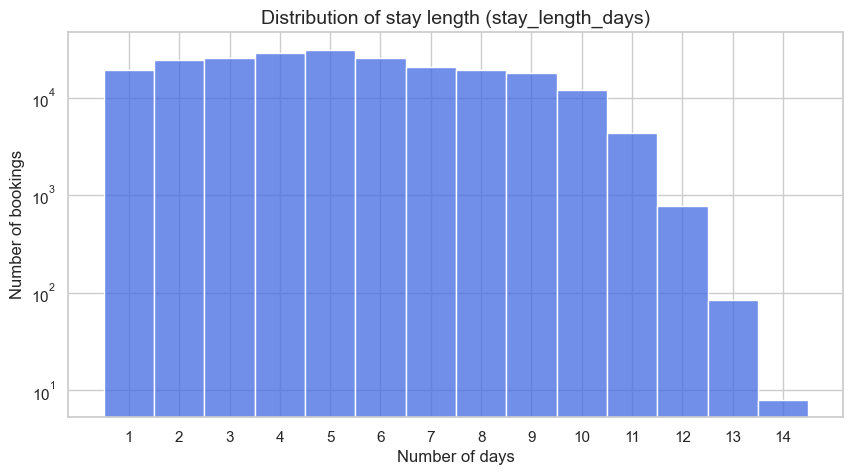


--- CONTINUOUS / QUASI-CONTINUOUS FEATURE DISTRIBUTIONS ---
count    199306.000000
mean        131.739832
std         290.827795
min           5.000000
25%          72.000000
50%         109.000000
75%         161.000000
max       50000.000000
Name: price_num, dtype: float64
count    228021.000000
mean          4.772684
std           0.177023
min           1.000000
25%           4.680000
50%           4.810000
75%           4.900000
max           5.000000
Name: review_scores_rating, dtype: float64
count    228021.000000
mean        257.358015
std         263.010352
min           1.000000
25%          80.000000
50%         189.000000
75%         343.000000
max        1628.000000
Name: number_of_reviews, dtype: float64


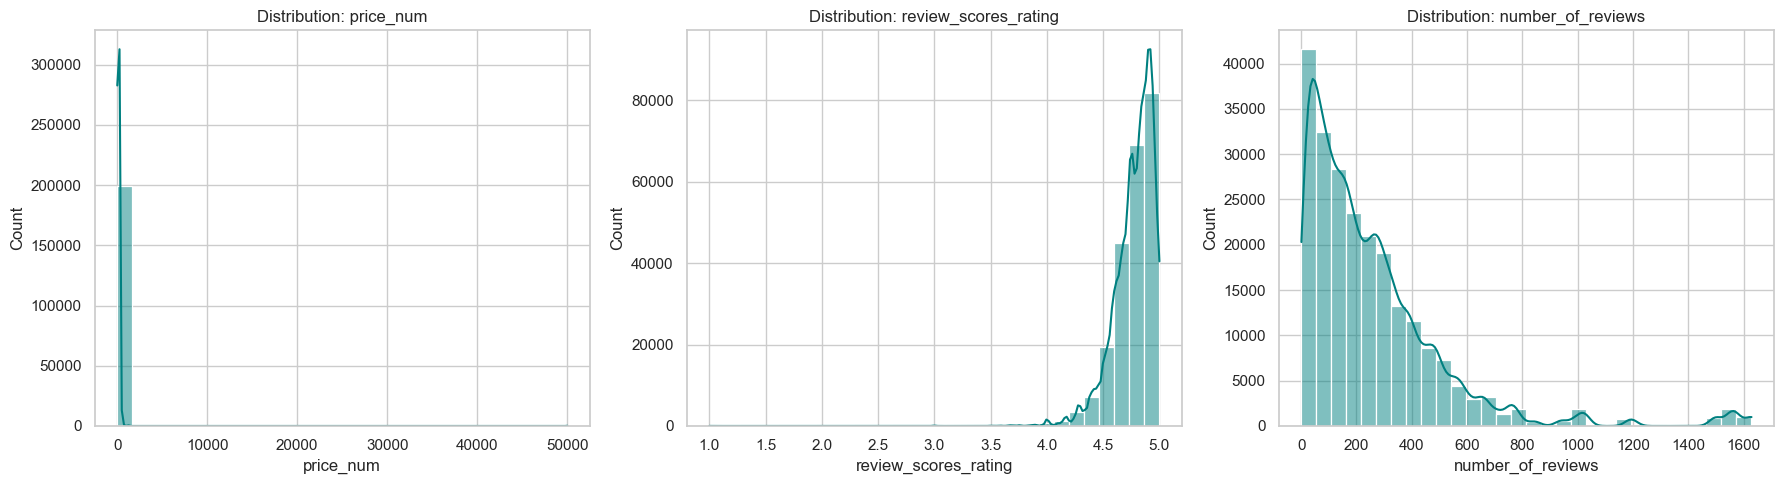

<Figure size 640x480 with 0 Axes>


--- DISCRETE FEATURE DISTRIBUTIONS ---
count    228021.000000
mean          3.530745
std           2.241138
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          16.000000
Name: accommodates, dtype: float64
count    199671.000000
mean          2.299513
std           1.733083
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          15.000000
Name: beds, dtype: float64
count    216200.000000
mean          1.341665
std           0.875472
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          14.000000
Name: bedrooms, dtype: float64


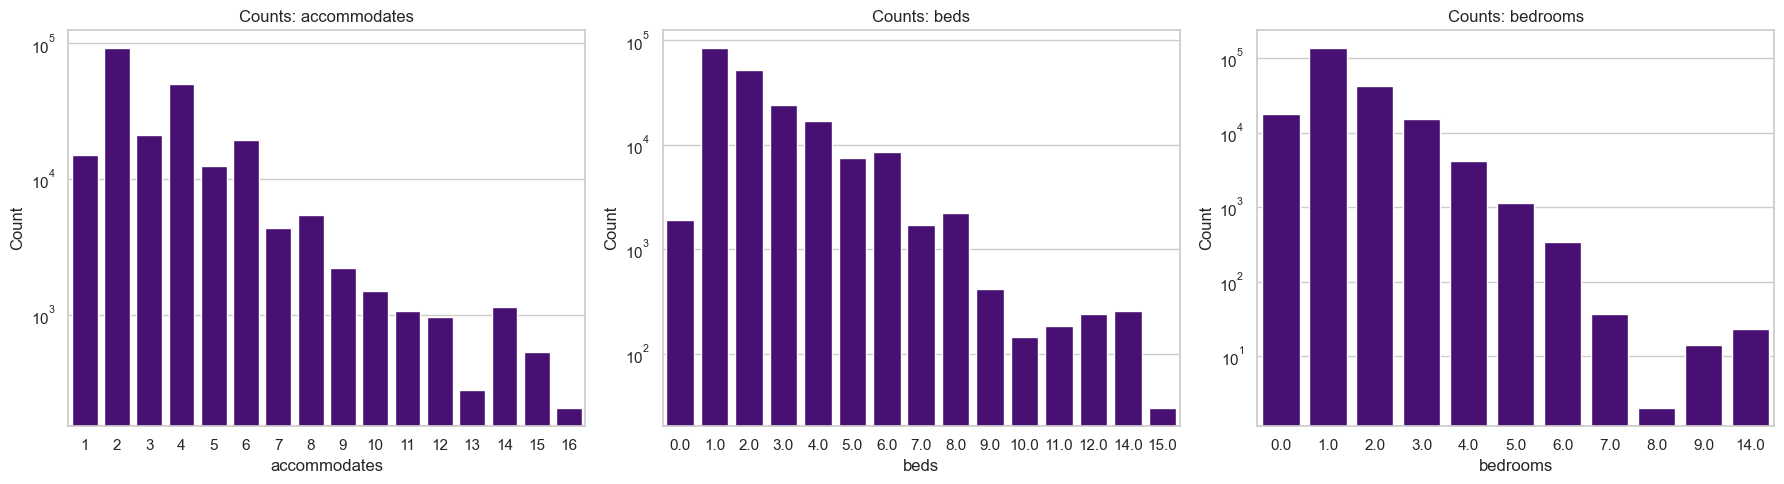

<Figure size 640x480 with 0 Axes>

In [6]:
sns.set_theme(style="whitegrid")

print("--- TARGET VARIABLE DISTRIBUTION ---")
plt.figure(figsize=(10, 5))
sns.histplot(merged_data['stay_length_days'], bins=14, discrete=True, color='royalblue')
plt.title('Distribution of stay length (stay_length_days)', fontsize=14)
plt.xlabel('Number of days', fontsize=12)
plt.ylabel('Number of bookings', fontsize=12)
plt.yscale('log')
plt.xticks(range(1, 15))
plt.show()

print("\n--- CONTINUOUS / QUASI-CONTINUOUS FEATURE DISTRIBUTIONS ---")
continuous_features = ['price_num', 'review_scores_rating', 'number_of_reviews']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(continuous_features):
    sns.histplot(merged_data[feature].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution: {feature}', fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(feature)
    print(merged_data[feature].describe())
plt.tight_layout()
plt.savefig('../results/continuous_features_distribution.png', bbox_inches='tight')
plt.show()

merged_data[continuous_features].describe().to_csv('../results/continuous_features_describe.csv')

plt.tight_layout()
plt.show()

print("\n--- DISCRETE FEATURE DISTRIBUTIONS ---")
discrete_features = ['accommodates', 'beds', 'bedrooms']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(discrete_features):
    sns.countplot(data=merged_data, x=feature, ax=axes[i], color='indigo')
    axes[i].set_title(f'Counts: {feature}', fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel(feature)
    axes[i].set_yscale('log')
    print(merged_data[feature].describe())
plt.tight_layout()
plt.savefig('../results/discrete_features_distribution.png', bbox_inches='tight')
plt.show()

merged_data[discrete_features].describe().to_csv('../results/discrete_features_describe.csv')

plt.tight_layout()
plt.show()